# Credit Card Fraud Detection

An end-to-end binary classification project detecting fraudulent credit card transactions from a highly imbalanced dataset (1.7% fraud rate, 339 of 20,000 transactions). Benchmark three models (Logistic Regression, Random Forest, and XGBoost) across two imbalance-handling strategies (class-weighting vs. SMOTE), using PR-AUC and ROC-AUC as primary evaluation metrics due to the severe class imbalance.

## Overview

Standard accuracy is misleading on this dataset (an "always legit" model scores 98.3% accuracy while catching zero fraud). This project instead prioritizes PR-AUC, threshold tuning, and precision/recall tradeoffs to build a model that's actually useful for flagging fraud in production.

## Dataset

- 20,000 transactions, 26 features, 0 missing values
- 1.70% fraud rate (339 of 20,000): a realistic, severe class imbalance
- Human-readable features (no PCA anonymization), including:
  - `merchant_risk_score`, `cvv_retry_count`, `velocity_score`, `ip_country_mismatch`
  - `billing_shipping_mismatch`, `distance_from_home_km`, `card_age_months`
  - `auth_method` (PIN, Biometric, 3D Secure, OTP, No Authentication)
  - `used_vpn`, `is_new_merchant`, `is_ai_generated_scam_attempt`

## Methodology

1. **Baseline model** — Random Forest, default settings
2. **Imbalance handling** — compared `class_weight='balanced'` vs. SMOTE oversampling across all model families
3. **Models benchmarked** — Logistic Regression (L2), Random Forest, XGBoost
4. **Threshold tuning** — optimized decision threshold per model (F1-maximizing) rather than relying on the default 0.5 cutoff
5. **Hyperparameter tuning** — grid search over `C`, penalty type (L1/L2/ElasticNet), and solver for the best-performing model (Logistic Regression)
6. **Feature interpretability** — Gini importance, and logistic regression odds ratios, cross-checked against each other

## Results

| Model | ROC-AUC | PR-AUC | Recall (tuned) | Precision (tuned) |
|---|---|---|---|---|
| Random Forest (Baseline) | 0.905 | 0.182 | 0.412 | 0.212 |
| **Logistic Regression (tuned)** | **0.941** | **0.451** | 0.515 | 0.422 |
| Logistic Regression (SMOTE) | 0.921 | 0.392 | 0.485 | 0.440 |
| Gradient Boosting | 0.923 | 0.338 | 0.324 | 0.512 |
| XGBoost | 0.921 | 0.271 | 0.485 | 0.266 |
| Random Forest (SMOTE) | 0.889 | 0.171 | 0.265 | 0.273 |

**Key findings:**
- Class-weighting consistently outperformed SMOTE across every model tested, likely because SMOTE's synthetic interpolation produces less realistic minority-class examples when the fraud class is very sparse (339 samples)
- The default 0.5 threshold caught **0 of 68** fraud cases in the baseline model, illustrating why threshold tuning is essential under severe imbalance
- Fraud risk appears largely linear/additive, so the tuned Logistic Regression outperformed all nonlinear tree-based ensembles

## Top Fraud Signals

Identified consistently across Gini importance and logistic regression odds ratios:

| Feature | Odds Ratio | Interpretation |
|---|---|---|
| `merchant_risk_score` | 1.71 | Strongest predictor of fraud |
| `cvv_retry_count` | 1.70 | Repeated CVV failures signal card-testing behavior |
| `velocity_score` | 1.55 | Rapid transaction velocity signals account takeover |
| `ip_country_mismatch` | 1.49 | Geographic inconsistency flags account compromise |
| `auth_method_No Authentication` | 1.47 | Weak authentication strongly increases risk |
| `auth_method_PIN` / `Biometric` | 0.85 | Strong authentication reduces fraud odds (as expected) |

## Tech Stack

- **Language/Core:** Python, pandas, NumPy
- **Modeling:** scikit-learn, imbalanced-learn (SMOTE), XGBoost
- **Evaluation:** PR-AUC, ROC-AUC, permutation importance, precision-recall curves
- **Visualization:** matplotlib
- **Persistence:** joblib

## How to Run

```bash
pip install -r requirements.txt
jupyter notebook fraud_detection.ipynb
```

## Future Work

- Explore feature engineering around transaction velocity (e.g., rolling counts over multiple time windows)
- Cost-sensitive threshold selection based on real business cost of false positives vs. false negatives
- Test on external/held-out time periods to assess temporal drift in fraud patterns

In [5]:
# Credit Card Fraud Classifier

import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv


In [6]:
df = pd.read_csv("/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv",index_col=0)

In [7]:
df.head()

,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
transaction_id,,,,,,,,,,,,,,,,,,,,,
1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,...,False,False,0,0.1,18,3,False,42.3,0,0
2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,...,False,False,0,25.8,12,4,False,28.3,0,0
3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,...,False,True,0,42.3,5,0,False,24.7,1,0
4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,...,False,False,0,28.9,22,6,False,56.2,1,0
5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,...,False,False,0,3.9,2,4,False,32.7,0,0


In [8]:
df.shape

(20000, 25)

In [9]:
df.describe()

,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [10]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="Data Profiling Report", explorative=True)
# profile.to_notebook_iframe()
# profile.to_file('Data_Profile.html')

In [11]:
from collections import Counter

# summarize the class distribution
target = df.values[:,-1]
counter = Counter(target)
for k,v in counter.items():
    per = v / len(target) * 100
    print('Class=%d, Count=%d, Percentage=%.3f%%' % (k, v, per))

Class=0, Count=19661, Percentage=98.305%
Class=1, Count=339, Percentage=1.695%


# EDA

In [12]:
import matplotlib.pyplot as plt

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20000
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   amount_usd                    20000 non-null  float64
 1   merchant_category             20000 non-null  object 
 2   card_type                     20000 non-null  object 
 3   auth_method                   20000 non-null  object 
 4   channel                       20000 non-null  object 
 5   device_type                   20000 non-null  object 
 6   is_foreign_transaction        20000 non-null  bool   
 7   hours_since_last_txn          20000 non-null  float64
 8   txn_count_last_24h            20000 non-null  int64  
 9   distance_from_home_km         20000 non-null  float64
 10  card_age_months               20000 non-null  int64  
 11  customer_age                  20000 non-null  int64  
 12  account_balance_usd           20000 non-null  float64
 13  is_new

### Initial Questions:
1. Can fraud be observed from retries and mismatch?
2. Does fraud have preference over certain methods?
3. Which 'merchant_category' faces the highest fraud?
4. Does time or distance matter?

In [14]:
# base rate for fraud
rate = df['is_fraud'].mean()

### Can fraud be observed from retries and mismatch?
- Columns: 'ip_country_mismatch', 'billing_shipping_mismatch', 'used_vpn', 'is_foreign_transaction', 'is_new_merchant', 'is_ai_generated_scam_attempt', 'cvv_retry_count'


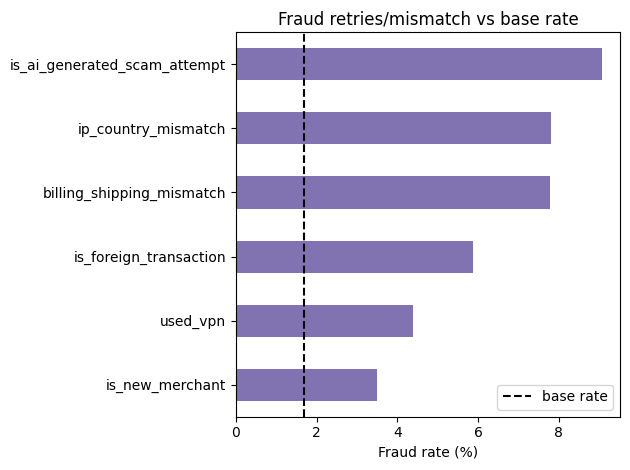

In [15]:
results = {}
flags = ['ip_country_mismatch', 'billing_shipping_mismatch', 'used_vpn',
         'is_foreign_transaction', 'is_new_merchant', 'is_ai_generated_scam_attempt']
for feature in flags:
    value = df.loc[df[feature], 'is_fraud'].mean() * 100
    results[feature] = value


feature_list = pd.Series(results).sort_values()

# print(feature_list)
ax = feature_list.plot(kind='barh', color='#8172B2')
ax.axvline(rate * 100, color='black', ls='--', label='base rate')
ax.set_xlabel('Fraud rate (%)')
ax.set_ylabel('')
ax.set_title('Fraud retries/mismatch vs base rate')
ax.legend()
plt.tight_layout()
plt.show()

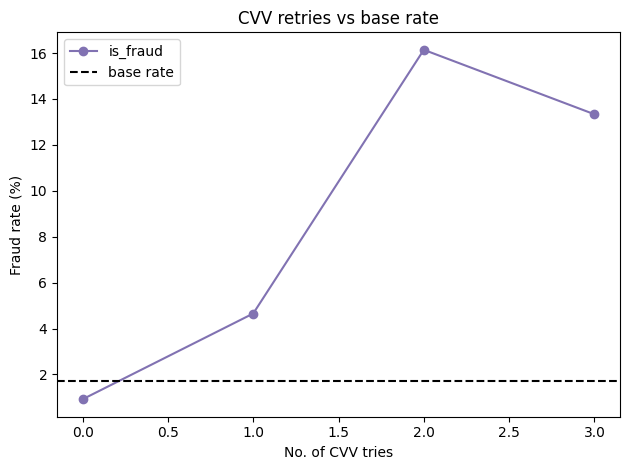

In [16]:
retry_rates = df.groupby('cvv_retry_count')['is_fraud'].mean() * 100

ax = retry_rates.plot(marker='o', color='#8172B2')
ax.axhline(rate * 100, color='black', ls='--', label='base rate')
ax.set_xlabel('No. of CVV tries')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('CVV retries vs base rate')
ax.legend()
plt.tight_layout()
plt.show()

It can be observed that:
- CVV retries are the most obvious factors to determine fraud
- All retries and mismatch are good signs of fraud

### Does fraud have preference over certain methods?
- Columns: auth_method, card_type, channel, device_type, customer_age

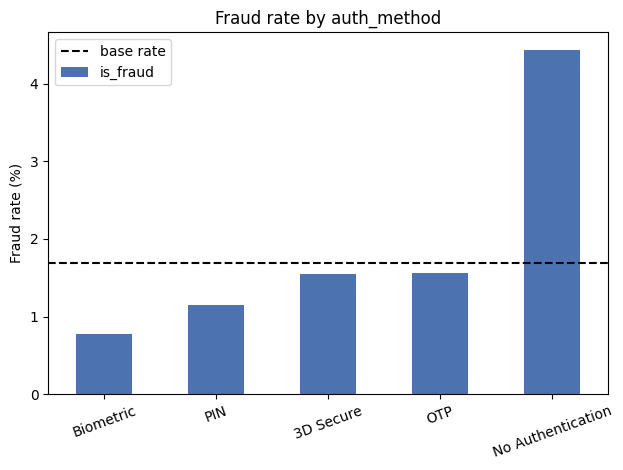

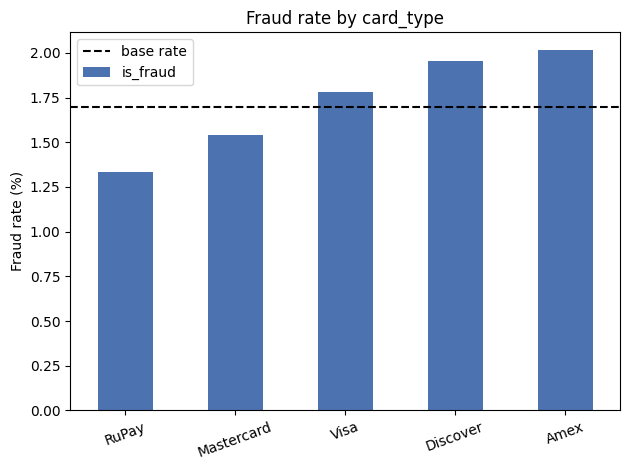

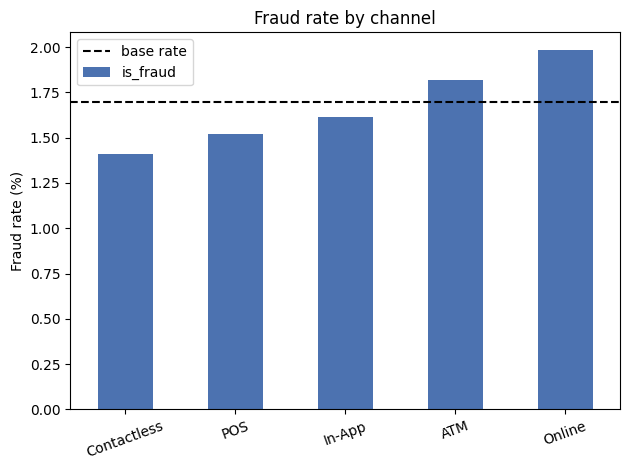

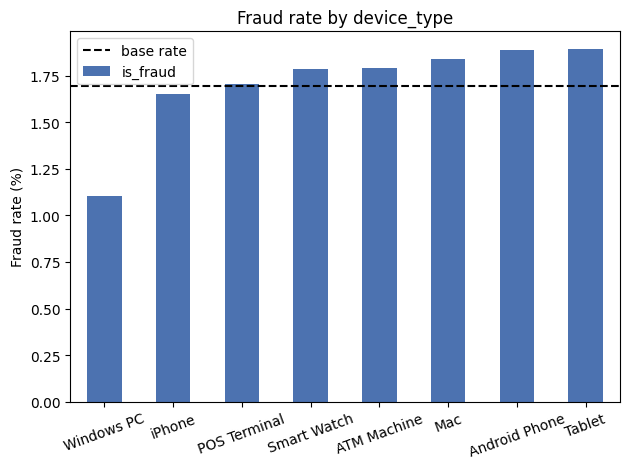

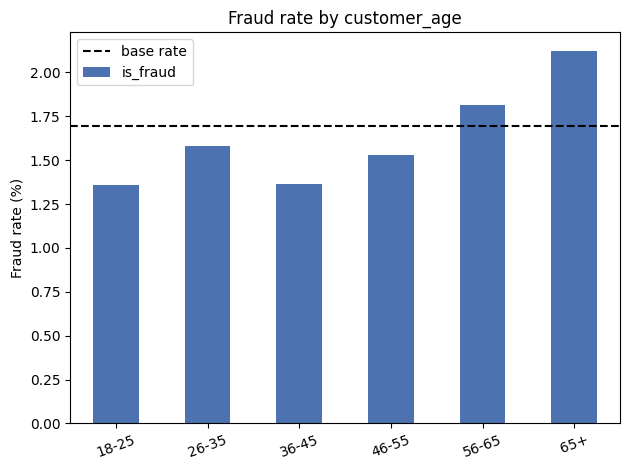

In [17]:
methods = ['auth_method', 'card_type', 'channel', 'device_type', 'customer_age']

age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['customer_age_bin'] = pd.cut(df['customer_age'], bins=age_bins, labels=age_labels, right=False)

for feature in methods:
    col = 'customer_age_bin' if feature == 'customer_age' else feature
    auth = (df.groupby(col, observed=True)['is_fraud'].mean() * 100)
    
    # keep age bins in natural order; sort other categoricals by rate
    if col != 'customer_age_bin':
        auth = auth.sort_values()
    
    ax = auth.plot(kind='bar', color='#4C72B0')
    ax.axhline(rate * 100, color='black', ls='--', label='base rate')
    ax.set_ylabel('Fraud rate (%)')
    ax.set_xlabel('')
    ax.set_title(f'Fraud rate by {feature}')
    plt.xticks(rotation=20)
    ax.legend()
    plt.tight_layout()
    plt.show()

It can be observed that:
- No authentication increases fraud rate as expected, and biometrics are the best way to suppress fraud
- Amex, Discover and Visa users are more likely to fall for frauds
- Contactless payments are resilient against frauds, unlike ATMs and online payment (especially from Mac, Android phones and tablets)
- Most victims are mainly the elderly above age 56 but there are trends among the young adults from age 26-35 as well

### Which 'merchant_category' faces the highest fraud?
- Columns: merchant_category

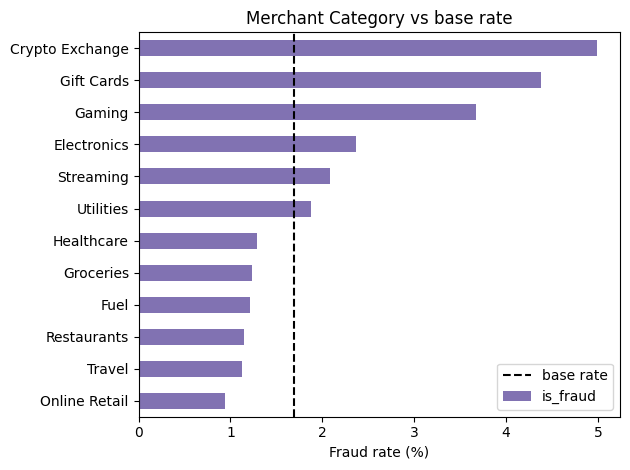

In [18]:
merchant_cat = (df.groupby('merchant_category')['is_fraud'].mean() * 100).sort_values()
ax = merchant_cat.plot(kind='barh', color='#8172B2')
ax.axvline(rate * 100, color='black', ls='--', label='base rate')
ax.set_xlabel('Fraud rate (%)')
ax.set_ylabel('')
ax.set_title('Merchant Category vs base rate')
ax.legend()
plt.tight_layout()
plt.show()

It can be observed that:
- Crypto exchange, gift cards and gaming are highly likely to fall for fraud

### Does time or distance matter?
- Columns: velocity_score, distance_from_home_km

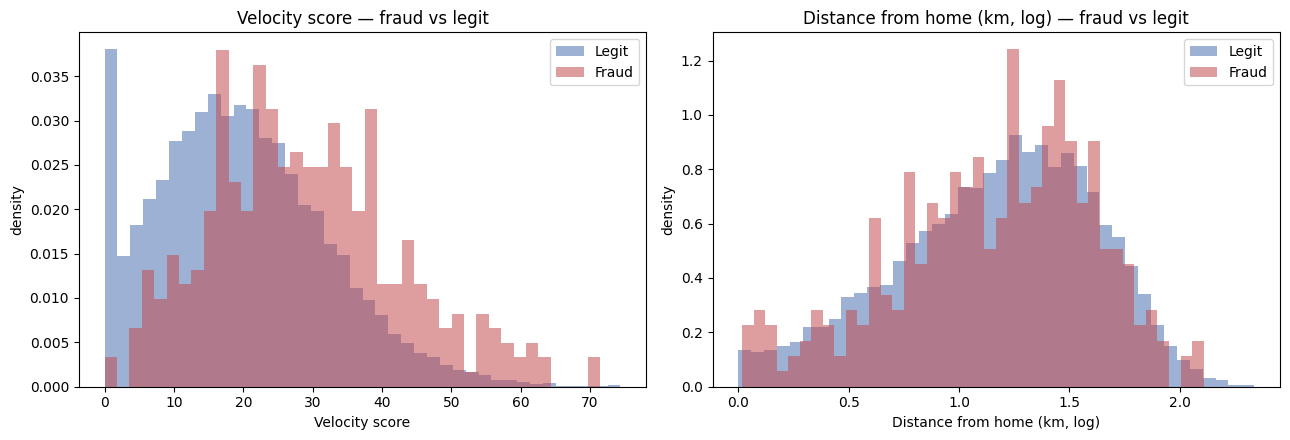

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(
    axes,
    ['velocity_score', 'distance_from_home_km'],
    ['Velocity score', 'Distance from home (km, log)'],
):
    for label, color, name in [(0, '#4C72B0', 'Legit'), (1, '#C44E52', 'Fraud')]:
        vals = df.loc[df.is_fraud == label, col]
        if col == 'distance_from_home_km':
            vals = np.log10(vals + 1)
        ax.hist(vals, bins=40, alpha=0.55, density=True, color=color, label=name)
    ax.set_xlabel(title)
    ax.set_ylabel('density')
    ax.legend()
    ax.set_title(f'{title} — fraud vs legit')
plt.tight_layout()
plt.show()

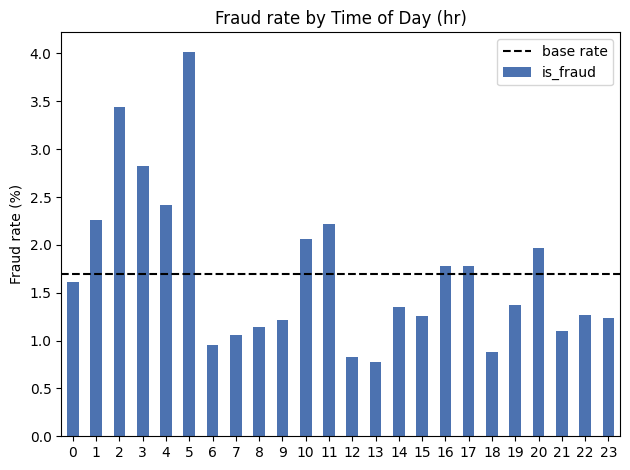

In [20]:
ts = df.groupby('time_of_day_hour')['is_fraud'].mean() * 100

ax = ts.plot(kind='bar', color='#4C72B0')
ax.axhline(rate * 100, color='black', ls='--', label='base rate')
ax.set_ylabel('Fraud rate (%)')
ax.set_xlabel('')
ax.set_title(f'Fraud rate by Time of Day (hr)')
plt.xticks(rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

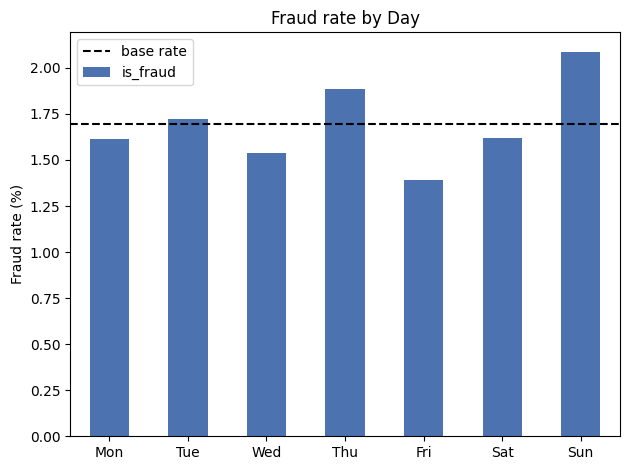

In [21]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ts = df.groupby('day_of_week')['is_fraud'].mean() * 100
ts.index = day_names

ax = ts.plot(kind='bar', color='#4C72B0')
ax.axhline(rate * 100, color='black', ls='--', label='base rate')
ax.set_ylabel('Fraud rate (%)')
ax.set_xlabel('')
ax.set_title(f'Fraud rate by Day')
plt.xticks(rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

It can be observed that:
- Fraudsters like to have it done fast and far away from their victims
- Fraud happens mainly in the early part of the day, either on Tues, Thu or Sun

# Baseline Model
Baseline: Random Forest Classifier
- Handles nonlinear relationships and feature interactions (e.g., velocity_score combined with hours_since_last_txn might matter jointly, not just additively)
- Fraud patterns are often interaction-heavy
- No need to worry about feature scaling, and it handles mixed feature types (binary flags like auth_method_No Authentication, continuous ones like distance_from_home_km) without preprocessing

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import mean
from numpy import std

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, GridSearchCV

from sklearn.metrics import (make_scorer, auc, average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve, roc_auc_score)

from sklearn.inspection import permutation_importance


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [23]:
# def load_df(path):
#     df = pd.read_csv(path, index_col=0)
#     X = df.drop(columns=["is_fraud"])
#     y = df["is_fraud"]
#     return X, y


df = pd.read_csv('/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv')

X = pd.get_dummies(df.drop(columns=["is_fraud", "transaction_id"]), drop_first=True)
y = df["is_fraud"]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, y_train.shape)


(20000, 49) (20000,)
(16000, 49) (16000,)


In [24]:
# baseline model
clf_model = RandomForestClassifier(n_estimators=300, 
                                   class_weight='balanced',
                                   random_state=42, 
                                   n_jobs=-1
                                  ).fit(X_train, y_train)

In [25]:
proba = clf_model.predict_proba(X_test)[:, 1]

print(f'PR-AUC  : {average_precision_score(y_test, proba):.3f}   (base rate = {y_test.mean():.4f})')
print(f'ROC-AUC : {roc_auc_score(y_test, proba):.3f}\n')

# Tuned F1 as accuracy is not feasible for fraud detection
prec_c, rec_c, thr_c = precision_recall_curve(y_test, proba)
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-12)
best_t = thr_c[f1_c.argmax()]
print(f'Default threshold 0.500 -> fraud caught: {((proba >= 0.5) & (y_test == 1)).sum()} of {y_test.sum()}')
print(f'Tuned   threshold {best_t:.3f} -> fraud caught: {((proba >= best_t) & (y_test == 1)).sum()} of {y_test.sum()}\n')

print(classification_report(y_test, (proba >= best_t).astype(int),
                            target_names=['Legit', 'Fraud'], digits=3))
print('Confusion matrix (tuned threshold):\n', confusion_matrix(y_test, (proba >= best_t).astype(int)))

PR-AUC  : 0.182   (base rate = 0.0170)
ROC-AUC : 0.905

Default threshold 0.500 -> fraud caught: 0 of 68
Tuned   threshold 0.077 -> fraud caught: 28 of 68

              precision    recall  f1-score   support

       Legit      0.990     0.974     0.982      3932
       Fraud      0.212     0.412     0.280        68

    accuracy                          0.964      4000
   macro avg      0.601     0.693     0.631      4000
weighted avg      0.976     0.964     0.970      4000

Confusion matrix (tuned threshold):
 [[3828  104]
 [  40   28]]


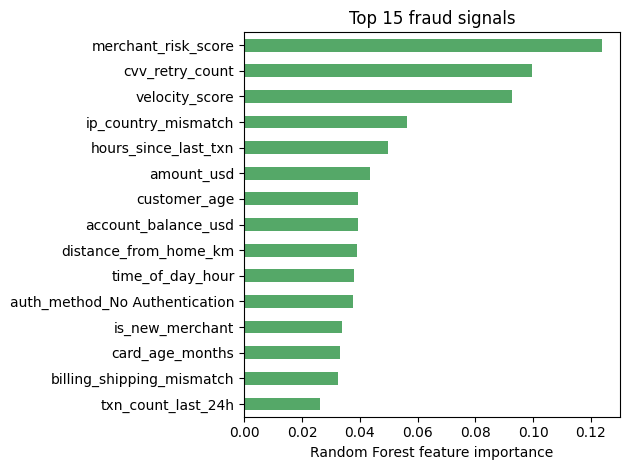

Top 3 signals:
  1. merchant_risk_score  (0.124)
  2. cvv_retry_count  (0.100)
  3. velocity_score  (0.093)


In [26]:
# feature_importances_ is Gini/impurity-based importance, which is known to be biased toward high-cardinality or continuous features, so another method using permutation importance can be used to cross check.
imp = pd.Series(clf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top = imp.head(15).sort_values()
ax = top.plot(kind='barh', color='#55A868')
ax.set_xlabel('Random Forest feature importance')
ax.set_title('Top 15 fraud signals')
plt.tight_layout()
plt.show()

print('Top 3 signals:')
for i, (name, val) in enumerate(imp.head(3).items(), 1):
    print(f'  {i}. {name}  ({val:.3f})')

### Baseline Model Summary:
The baseline Random Forest fraud classifier achieves a ROC-AUC of 0.905 and PR-AUC of 0.182, which given the severe class imbalance (base fraud rate of only 1.7%), represents roughly a 10.7x lift over random guessing on the minority class. At the default 0.5 threshold, the model fails completely in practice, catching 0 of 68 fraud cases, since predicted probabilities are compressed well below 0.5 due to the imbalance. 

After tuning the decision threshold down to 0.077, the model catches 28 of 68 frauds (41% recall) at a fraud precision of 21.2%, producing 104 false positives against 28 true positives. This reflects a meaningful but incomplete fraud-detection capability where the model still misses 59% of fraud cases, so threshold choice must ultimately be driven by the relative business cost of false positives (blocked/reviewed legitimate transactions) versus false negatives (undetected fraud). 

Feature importance analysis shows the model relies most heavily on merchant risk score, cvv retry count, and velocity score, followed by ip country mismatch and hours since last transaction. All these flags are intuitively sensible fraud signals, which is a good sign against data leakage or spurious correlations.

### Next steps:
- Addressing class imbalance with SMOTE
- Cross check Gini-based feature importance (bias towards high-cardinality features) with another feature importance method
- Compare other models like Logisitic Regression (L2) / Gradient Boosting

# Model Evaluation

In [30]:
# ======================== No SMOTE ========================
# Baseline Random Forest
rf_baseline = RandomForestClassifier(
        n_estimators=300, 
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

# Logistic Regression
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2',
        class_weight='balanced', 
        max_iter=1000,
        random_state=42
    ))
])

# XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',     # optimize for PR-AUC directly during training
    random_state=42,
    n_jobs=-1
)
# ======================== SMOTE ========================

# Random Forest but with smote
rf_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

# Logistic Regression
lr_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', max_iter=1000, random_state=42))
])

# XGBoost
xgb_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
        # note: no scale_pos_weight here, since SMOTE already balances classes
    ))
])

models_smote = {
    'Random Forest (Baseline)': rf_baseline,
    'Logistic Regression': lr,
    'XGBoost': xgb,
    'Random Forest (SMOTE)': rf_smote,
    'Logistic Regression (SMOTE)': lr_smote,
    'XGBoost (SMOTE)': xgb_smote
}

In [31]:
# Find best threshold (maximize F1 on fraud class)
def best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.argmax(f1s[:-1])  # last point has no threshold
    return thresholds[best_idx], f1s[best_idx]


results_smote = []
roc_curves_smote = {}

for name, model in models_smote.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, -1]

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    thresh, f1 = best_threshold(y_test, y_proba)

    y_pred_default = (y_proba >= 0.5).astype(int)
    y_pred_tuned = (y_proba >= thresh).astype(int)

    total_fraud = (y_test == 1).sum()
    fraud_caught_default = ((y_pred_default == 1) & (y_test == 1)).sum()
    fraud_caught_tuned = ((y_pred_tuned == 1) & (y_test == 1)).sum()

    results_smote.append({
        'Model': name,
        'ROC-AUC': round(roc_auc, 3),
        'PR-AUC': round(pr_auc, 3),
        'Best Threshold': round(thresh, 3),
        'Fraud Caught @0.5': f'{fraud_caught_default} of {total_fraud}',
        'Fraud Caught @tuned': f'{fraud_caught_tuned} of {total_fraud}',
        'Precision (tuned)': round(
            ((y_pred_tuned == 1) & (y_test == 1)).sum() / max((y_pred_tuned == 1).sum(), 1), 3
        ),
        'Recall (tuned)': round(fraud_caught_tuned / total_fraud, 3),
    })

    roc_curves_smote[name] = y_proba

comparison_smote_df = pd.DataFrame(results_smote)

# full_comparison = pd.concat([comparison_df, comparison_smote_df], ignore_index=True)
print(comparison_smote_df.to_string(index=False))
    

                      Model  ROC-AUC  PR-AUC  Best Threshold Fraud Caught @0.5 Fraud Caught @tuned  Precision (tuned)  Recall (tuned)
   Random Forest (Baseline)    0.905   0.182           0.077           0 of 68            28 of 68              0.212           0.412
        Logistic Regression    0.934   0.440           0.967          55 of 68            27 of 68              0.529           0.397
                    XGBoost    0.921   0.271           0.735          51 of 68            33 of 68              0.266           0.485
      Random Forest (SMOTE)    0.889   0.171           0.340           7 of 68            18 of 68              0.273           0.265
Logistic Regression (SMOTE)    0.921   0.392           0.412          29 of 68            33 of 68              0.440           0.485
            XGBoost (SMOTE)    0.894   0.235           0.569          22 of 68            20 of 68              0.267           0.294


### Summary of Model Selection
- Model Selected: Logistic Regression (L2). It has the highest ROC-AUC (0.934) and PR-AUC (0.44). It also has the highest precision over the other models. What this means is that the Logistic Regression model without SMOTE is able to catch the most fraud out of all models while maintaining high precision.
- SMOTE actually decreases the performances of models. After some research, it was found that SMOTE generates synthetic points by interpolating between minority-class neighbors, and tree-based ensembles can overfit to the resulting synthetic decision boundaries/artifacts, especially when the minority class is very sparse (only 339 fraud cases here). Trees split on exact regions, so synthetic points can create "fake" splits that don't generalize. Linear models tend to be less sensitive to this because they fit a single global boundary rather than local partitions.

# Model Hyperparameter Optimization
- Model: Logistic Regression (L2)

In [32]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

param_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['lbfgs', 'saga']
    },
    {
        'clf__penalty': ['l1'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['saga', 'liblinear']
    },
    {
        'clf__penalty': ['elasticnet'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['saga'],
        'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    lr_pipe,
    param_grid = param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'clf__penalty': ['l2'],
                          'clf__solver': ['lbfgs', 'saga']},
                         {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'clf__penalty': ['l1'],
                          'clf__solver': ['saga', 'liblinear']},
                         {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
                          'clf__penalty': ['elasticnet'],
                          'clf__solver': ['saga']}],
             scoring='average_precision', verbose=1)

In [33]:
print("Best params:", gs.best_params_)
print("Best CV PR-AUC:", round(gs.best_score_, 3))

# Best params: {'clf__C': 0.001, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
# Best CV PR-AUC: 0.413

Best params: {'clf__C': 0.001, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
Best CV PR-AUC: 0.413


In [39]:
import joblib
# joblib.dump(lr_pipe, 'lr_model.pkl')
# loaded_lr_model = joblib.load('lr_model.pkl')

models_dict = {
    'lr_model': best_lr,
    'lr_gs': gs
}

# Dump everything into a single file
joblib.dump(models_dict, '/kaggle/working/all_models.joblib')

# How to load them back
# loaded_models = joblib.load('/kaggle/working/all_models.joblib')
# lr = loaded_models['lr_model']
# y_proba = lr.predict_proba(X_test)[:,1]

['/kaggle/working/all_models.joblib']

In [36]:
# Evaluating tuned model on held-out testset
best_lr = gs.best_estimator_
print('Best estimator:', best_lr)

y_proba = best_lr.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
thresh, f1 = best_threshold(y_test, y_proba)   

y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_tuned = (y_proba >= thresh).astype(int)

total_fraud = (y_test == 1).sum()
fraud_caught_default = ((y_pred_default == 1) & (y_test == 1)).sum()
fraud_caught_tuned = ((y_pred_tuned == 1) & (y_test == 1)).sum()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Best threshold: {thresh:.3f}")
print(f"Fraud caught @0.5: {fraud_caught_default} of {total_fraud}")
print(f"Fraud caught @tuned: {fraud_caught_tuned} of {total_fraud}")
print(f"Precision (tuned): {((y_pred_tuned==1)&(y_test==1)).sum() / max((y_pred_tuned==1).sum(),1):.3f}")
print(f"Recall (tuned): {fraud_caught_tuned/total_fraud:.3f}")

Best estimator: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    l1_ratio=0.1, max_iter=5000,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])
ROC-AUC: 0.941
PR-AUC: 0.451
Best threshold: 0.829
Fraud caught @0.5: 55 of 68
Fraud caught @tuned: 35 of 68
Precision (tuned): 0.422
Recall (tuned): 0.515


In [38]:
feature_names = X_train.columns
coefs = best_lr.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs)   # interpretable: >1 increases fraud odds, <1 decreases
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.head(15))

                            feature  coefficient  odds_ratio
17              merchant_risk_score     0.535771    1.708765
12                  cvv_retry_count     0.533539    1.704955
13                   velocity_score     0.440729    1.553840
10              ip_country_mismatch     0.395812    1.485590
35    auth_method_No Authentication     0.383127    1.466864
11        billing_shipping_mismatch     0.336333    1.399805
8                   is_new_merchant     0.334690    1.397506
9                          used_vpn     0.256444    1.292327
1            is_foreign_transaction     0.213216    1.237652
16     is_ai_generated_scam_attempt     0.188352    1.207259
37                  auth_method_PIN    -0.166602    0.846536
34            auth_method_Biometric    -0.160897    0.851380
18                   prior_disputes     0.120335    1.127874
25  merchant_category_Online Retail    -0.090670    0.913319
6                      customer_age     0.084494    1.088166


### Summary of Model's hyperparameter optimization:

1. Model Selected: Logistic Regression (L2)
- ROC-AUC: 0.934
- PR-AUC: 0.440
- Best threshold: 0.967
- Fraud caught @0.5: 55 of 68
- Fraud caught @tuned: 27 of 68
- Precision (tuned): 0.529
- Recall (tuned): 0.397

2. After hyperparamater tuning:
- ROC-AUC: 0.941
- PR-AUC: 0.451
- Best threshold: 0.829
- Fraud caught @0.5: 55 of 68
- Fraud caught @tuned: 35 of 68
- Precision (tuned): 0.422
- Recall (tuned): 0.515

Hyperparameter tuning improved the Logistic Regression (L2) model modestly but meaningfully across all metrics: ROC-AUC rose from 0.934 to 0.941 and PR-AUC from 0.440 to 0.451. More importantly, the tuned model shifted the precision-recall tradeoff toward better fraud coverage, where the recall improved substantially from 0.397 to 0.515 (35 of 68 fraud cases caught, up from 27), at the cost of precision dropping from 0.529 to 0.422. However, this is a favorable tradeoff for a fraud detection context, where catching more fraud is typically prioritized over minimizing false positives, provided the false-positive volume remains operationally manageable (in this case, a lower best-threshold of 0.829 vs. 0.967 reflects the regularization tuning recalibrating the model's confidence distribution).

Examining the tuned model's coefficients (converted to odds ratios) confirms the feature importance patterns seen earlier with Random Forest, adding a clean linear interpretation on top: merchant_risk_score (odds ratio 1.71), cvv_retry_count (1.70), and velocity_score (1.55) remain the three strongest fraud signals, meaning each one-unit increase in these features multiplies the odds of fraud by roughly 1.5–1.7x, holding other features constant. Notably, auth_method_No Authentication (odds ratio 1.47) stands out as a strong risk signal, while auth_method_PIN (0.85) and auth_method_Biometric (0.85) both reduce fraud odds. This is an intuitive and reassuring result since stronger authentication methods should logically correlate with lower fraud risk. Other notable risk-increasing signals include ip_country_mismatch (1.49), billing_shipping_mismatch (1.40), is_new_merchant (1.40), and used_vpn (1.29), all consistent with common real-world fraud heuristics. This alignment between the linear coefficients and the earlier tree-based feature importances (Gini) strengthens confidence that these signals represent genuine fraud patterns in the data rather than model-specific artifacts.

# Conclusion of Credit Card Fraud Detection:

Across all models evaluated (Random Forest, XGBoost, and Logistic Regression), each tested with and without SMOTE, the **Logistic Regression (L2, class-weighted, tuned)** emerged as the best-performing model, achieving the highest ROC-AUC (0.941) and PR-AUC (0.451) of any configuration tested. 

This result suggests that fraud risk in this dataset is largely captured by linear, additive relationships between features rather than requiring complex nonlinear interactions, and that proper class-weighting was consistently more effective than SMOTE across every algorithm tried. Beyond its strong quantitative performance, Logistic Regression offers a key practical advantage for a fraud detection use case: full interpretability via odds ratios, allowing each flagged transaction to be explained in terms of concrete, actionable risk factors (e.g., elevated merchant risk score, repeated CVV retries, mismatched IP country) rather than an opaque black-box score. 

At the tuned threshold of 0.829, the final model catches 35 of 68 fraud cases (51.5% recall) at 42.2% precision, a reasonable operating point for a first-pass fraud flagging system, though the optimal threshold should ultimately be revisited alongside the business's specific cost tolerance for false positives versus undetected fraud.